<a href="https://colab.research.google.com/github/Meshari-glitch/HAR-ML-Framework/blob/main/HAR_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Human Activity Recognition — ML Framework
**Author:** Meshari Saud Alaskar | [GitHub](https://github.com/Meshari-glitch)


In [5]:
!pip install xgboost -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

print('✅ Libraries ready | TF:', tf.__version__)

✅ Libraries ready | TF: 2.20.0


## Load Dataset

In [6]:
import urllib.request
import zipfile

print('Downloading dataset...')
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip'
urllib.request.urlretrieve(url, 'har.zip')

with zipfile.ZipFile('har.zip', 'r') as z:
    z.extractall('.')

base = 'UCI HAR Dataset/'

X_train = pd.read_csv(base + 'train/X_train.txt', delim_whitespace=True, header=None)
X_test  = pd.read_csv(base + 'test/X_test.txt',  delim_whitespace=True, header=None)
y_train = pd.read_csv(base + 'train/y_train.txt', delim_whitespace=True, header=None, names=['Activity'])
y_test  = pd.read_csv(base + 'test/y_test.txt',  delim_whitespace=True, header=None, names=['Activity'])

activity_map = {1:'WALKING', 2:'WALKING_UPSTAIRS', 3:'WALKING_DOWNSTAIRS',
                4:'SITTING', 5:'STANDING', 6:'LAYING'}

y_train['Activity'] = y_train['Activity'].map(activity_map)
y_test['Activity']  = y_test['Activity'].map(activity_map)
y_train = y_train['Activity']
y_test  = y_test['Activity']

print(f'✅ Train: {X_train.shape} | Test: {X_test.shape}')
print(y_train.value_counts())

✅ Train: (7352, 561) | Test: (2947, 561)
Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


## EDA

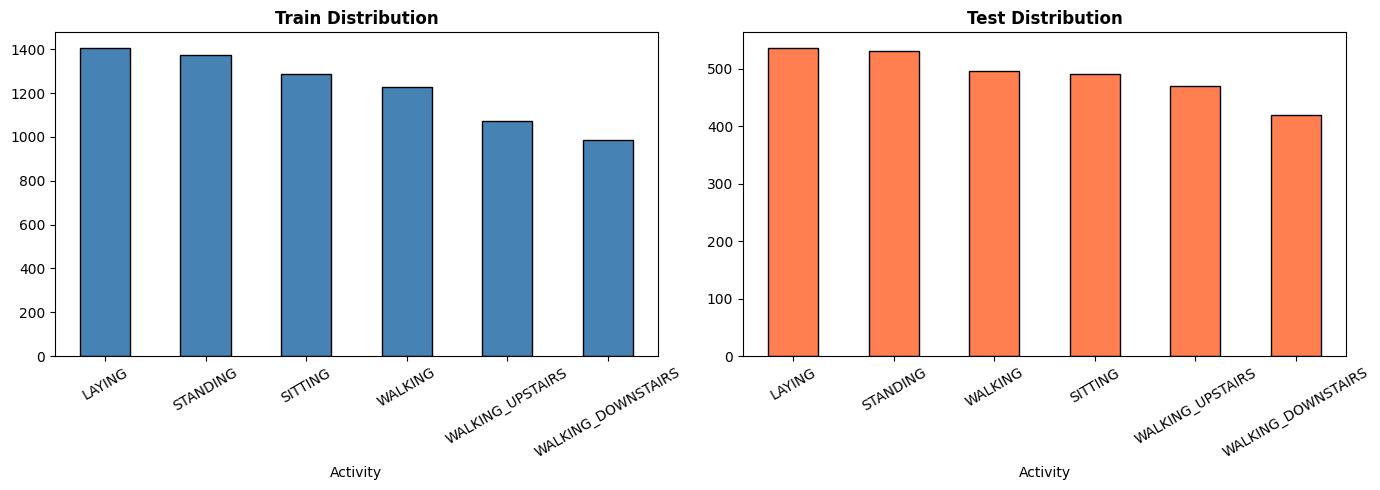

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
y_train.value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Train Distribution', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
y_test.value_counts().plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Test Distribution', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## Prepare Data

In [8]:
le = LabelEncoder()
le.fit(y_train)
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)
y_train_cat = to_categorical(y_train_enc)
y_test_cat  = to_categorical(y_test_enc)
X_train_dl  = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_dl   = X_test.values.reshape(X_test.shape[0],  X_test.shape[1],  1)
LABELS   = list(activity_map.values())
results  = {}
print('✅ Ready | DL shape:', X_train_dl.shape)

✅ Ready | DL shape: (7352, 561, 1)


## Helper: Confusion Matrix

In [9]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title, fontweight='bold')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

## SVM

Training SVM... (2-3 min)
✅ SVM: 96.20%
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.98      0.89      0.93       491
          STANDING       0.91      0.98      0.95       532
           WALKING       0.96      0.99      0.97       496
WALKING_DOWNSTAIRS       0.99      0.94      0.97       420
  WALKING_UPSTAIRS       0.94      0.96      0.95       471

          accuracy                           0.96      2947
         macro avg       0.96      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947



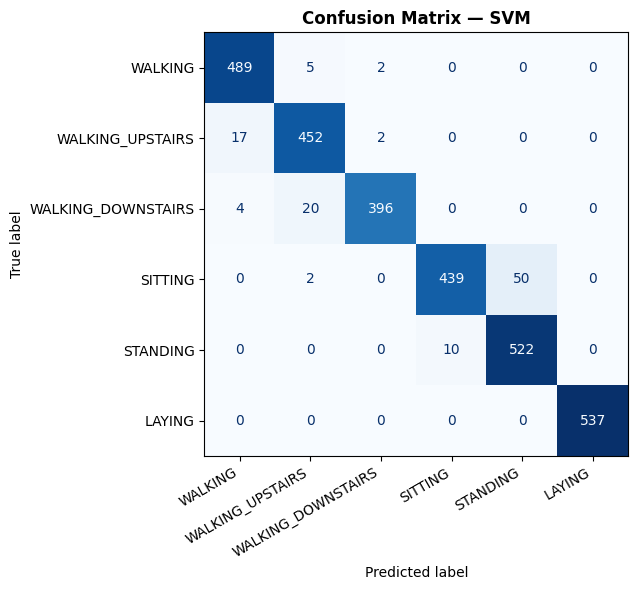

In [10]:
print('Training SVM... (2-3 min)')
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
acc = accuracy_score(y_test, y_pred)
results['SVM'] = round(acc*100, 2)
print(f'✅ SVM: {acc*100:.2f}%')
print(classification_report(y_test, y_pred))
plot_cm(y_test, y_pred, 'Confusion Matrix — SVM')

## KNN

Training KNN...
✅ KNN: 90.02%
                    precision    recall  f1-score   support

            LAYING       1.00      0.99      1.00       537
           SITTING       0.91      0.79      0.85       491
          STANDING       0.83      0.93      0.88       532
           WALKING       0.85      0.98      0.91       496
WALKING_DOWNSTAIRS       0.94      0.79      0.86       420
  WALKING_UPSTAIRS       0.90      0.89      0.89       471

          accuracy                           0.90      2947
         macro avg       0.90      0.90      0.90      2947
      weighted avg       0.90      0.90      0.90      2947



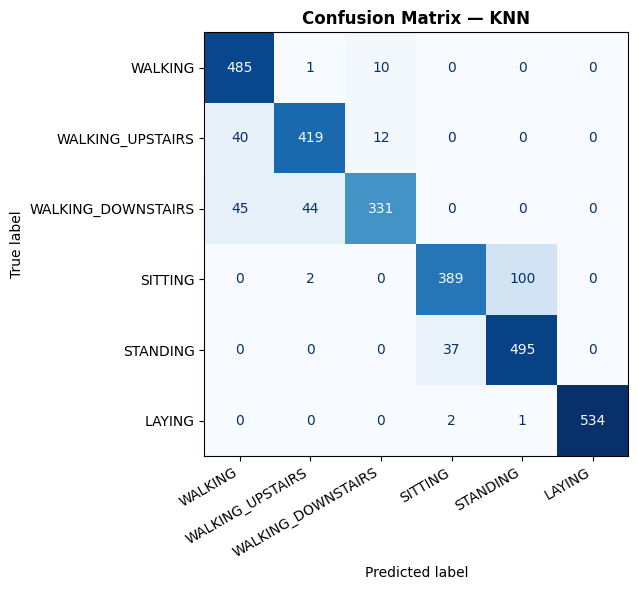

In [11]:
print('Training KNN...')
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
acc = accuracy_score(y_test, y_pred)
results['KNN'] = round(acc*100, 2)
print(f'✅ KNN: {acc*100:.2f}%')
print(classification_report(y_test, y_pred))
plot_cm(y_test, y_pred, 'Confusion Matrix — KNN')

## Decision Tree

Training Decision Tree...
✅ Decision Tree: 86.22%
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.83      0.76      0.80       491
          STANDING       0.80      0.86      0.83       532
           WALKING       0.83      0.92      0.87       496
WALKING_DOWNSTAIRS       0.89      0.83      0.86       420
  WALKING_UPSTAIRS       0.83      0.78      0.80       471

          accuracy                           0.86      2947
         macro avg       0.86      0.86      0.86      2947
      weighted avg       0.86      0.86      0.86      2947



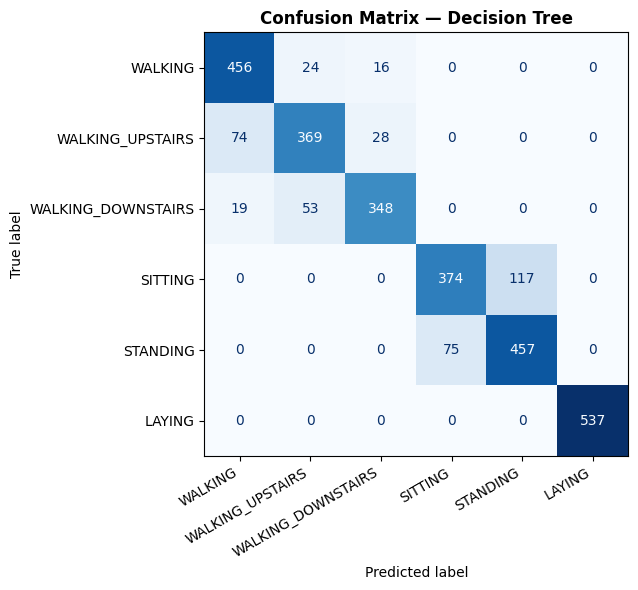

In [12]:
print('Training Decision Tree...')
dtc = DecisionTreeClassifier(max_depth=20, random_state=42)
dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)
acc = accuracy_score(y_test, y_pred)
results['Decision Tree'] = round(acc*100, 2)
print(f'✅ Decision Tree: {acc*100:.2f}%')
print(classification_report(y_test, y_pred))
plot_cm(y_test, y_pred, 'Confusion Matrix — Decision Tree')

## Random Forest

Training Random Forest...
✅ Random Forest: 92.67%
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.91      0.90      0.90       491
          STANDING       0.91      0.92      0.91       532
           WALKING       0.89      0.97      0.93       496
WALKING_DOWNSTAIRS       0.97      0.87      0.92       420
  WALKING_UPSTAIRS       0.89      0.89      0.89       471

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



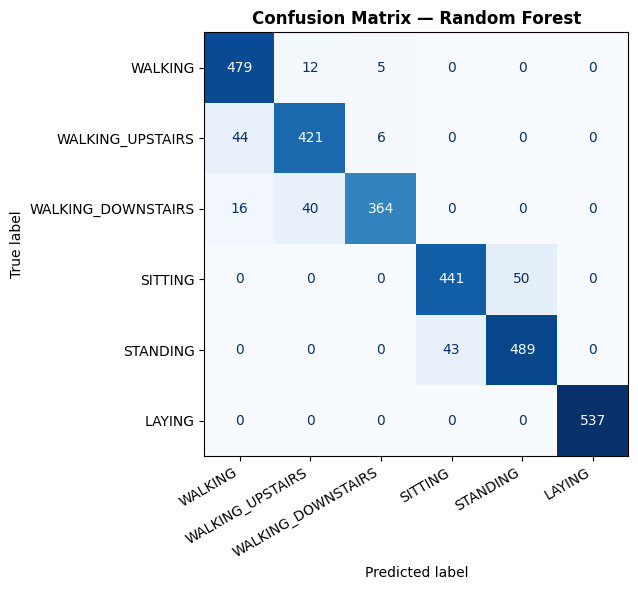

In [13]:
print('Training Random Forest...')
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
results['Random Forest'] = round(acc*100, 2)
print(f'✅ Random Forest: {acc*100:.2f}%')
print(classification_report(y_test, y_pred))
plot_cm(y_test, y_pred, 'Confusion Matrix — Random Forest')

## XGBoost

Training XGBoost...
✅ XGBoost: 93.55%
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.93      0.85      0.89       491
          STANDING       0.88      0.94      0.91       532
           WALKING       0.92      0.98      0.95       496
WALKING_DOWNSTAIRS       0.97      0.92      0.94       420
  WALKING_UPSTAIRS       0.92      0.91      0.92       471

          accuracy                           0.94      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.94      0.94      2947



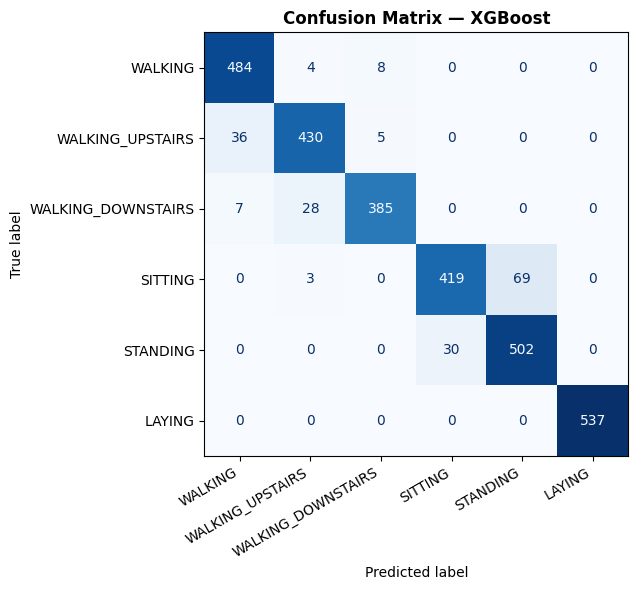

In [14]:
print('Training XGBoost...')
xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                    eval_metric='mlogloss', random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train_enc)
y_pred = le.inverse_transform(xgb.predict(X_test))
acc = accuracy_score(y_test, y_pred)
results['XGBoost'] = round(acc*100, 2)
print(f'✅ XGBoost: {acc*100:.2f}%')
print(classification_report(y_test, y_pred))
plot_cm(y_test, y_pred, 'Confusion Matrix — XGBoost')

## CNN

Training CNN...
Epoch 1/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 30s 236ms/step - accuracy: 0.8550 - loss: 0.6723 - val_accuracy: 0.3502 - val_loss: 2.2955
Epoch 2/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 43s 253ms/step - accuracy: 0.9527 - loss: 0.1223 - val_accuracy: 0.4642 - val_loss: 2.1490
Epoch 3/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 27s 234ms/step - accuracy: 0.9621 - loss: 0.0953 - val_accuracy: 0.6413 - val_loss: 0.7185
Epoch 4/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 28s 244ms/step - accuracy: 0.9757 - loss: 0.0670 - val_accuracy: 0.9332 - val_loss: 0.1798
Epoch 5/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 27s 236ms/step - accuracy: 0.9804 - loss: 0.0519 - val_accuracy: 0.9484 - val_loss: 0.1340
Epoch 6/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 42s 364ms/step - accuracy: 0.9785 - loss: 0.0574 - val_accuracy: 0.9654 - val_loss: 0.0962
Epoch 7/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 26s 226ms/step - accuracy: 0.9844 - loss: 0.0399 - val_accuracy: 0.9423 - val_loss: 0.1684
Epoch 8/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 26s 223ms/step - accuracy: 

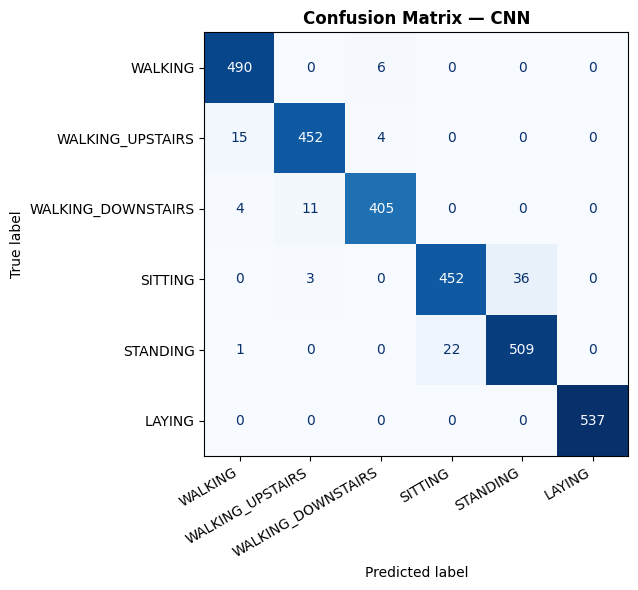

In [15]:
print('Training CNN...')
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
cnn = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(X_train_dl.shape[1], 1)),
    BatchNormalization(), MaxPooling1D(2),
    Conv1D(128, 3, activation='relu'),
    BatchNormalization(), MaxPooling1D(2),
    Flatten(), Dense(128, activation='relu'), Dropout(0.3),
    Dense(6, activation='softmax')
])
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn.fit(X_train_dl, y_train_cat, epochs=15, batch_size=64,
        validation_data=(X_test_dl, y_test_cat), callbacks=[es], verbose=1)
y_pred = le.inverse_transform(np.argmax(cnn.predict(X_test_dl), axis=1))
acc = accuracy_score(y_test, y_pred)
results['CNN'] = round(acc*100, 2)
print(f'✅ CNN: {acc*100:.2f}%')
print(classification_report(y_test, y_pred))
plot_cm(y_test, y_pred, 'Confusion Matrix — CNN')

## LSTM

Training LSTM...
Epoch 1/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 221s 2s/step - accuracy: 0.3052 - loss: 1.4206 - val_accuracy: 0.3651 - val_loss: 1.1197
Epoch 2/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 234s 2s/step - accuracy: 0.3988 - loss: 1.1071 - val_accuracy: 0.4578 - val_loss: 1.0964
Epoch 3/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 215s 2s/step - accuracy: 0.4434 - loss: 1.0706 - val_accuracy: 0.4869 - val_loss: 1.0512
93/93 ━━━━━━━━━━━━━━━━━━━━ 29s 306ms/step
✅ LSTM: 36.51%
                    precision    recall  f1-score   support

            LAYING       0.34      0.98      0.51       537
           SITTING       0.00      0.00      0.00       491
          STANDING       0.00      0.00      0.00       532
           WALKING       0.00      0.00      0.00       496
WALKING_DOWNSTAIRS       0.34      0.92      0.50       420
  WALKING_UPSTAIRS       0.58      0.34      0.43       471

          accuracy                           0.37      2947
         macro avg       0.21      0.37      0.24      29

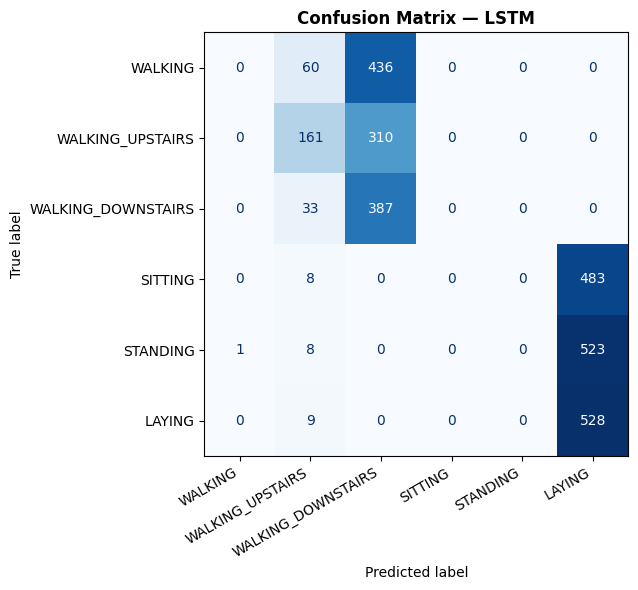

In [18]:
print('Training LSTM...')
lstm = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_train_dl.shape[1], 1)),
    Dropout(0.3), LSTM(64), Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])
lstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm.fit(X_train_dl, y_train_cat, epochs=15, batch_size=64,
         validation_data=(X_test_dl, y_test_cat), callbacks=[es], verbose=1)
y_pred = le.inverse_transform(np.argmax(lstm.predict(X_test_dl), axis=1))
acc = accuracy_score(y_test, y_pred)
results['LSTM'] = round(acc*100, 2)
print(f'✅ LSTM: {acc*100:.2f}%')
print(classification_report(y_test, y_pred))
plot_cm(y_test, y_pred, 'Confusion Matrix — LSTM')

## Final Comparison

     FINAL MODEL COMPARISON
        Model  Accuracy (%)
          CNN         96.54
          SVM         96.20
      XGBoost         93.55
Random Forest         92.67
          KNN         90.02
Decision Tree         86.22
         LSTM         36.51


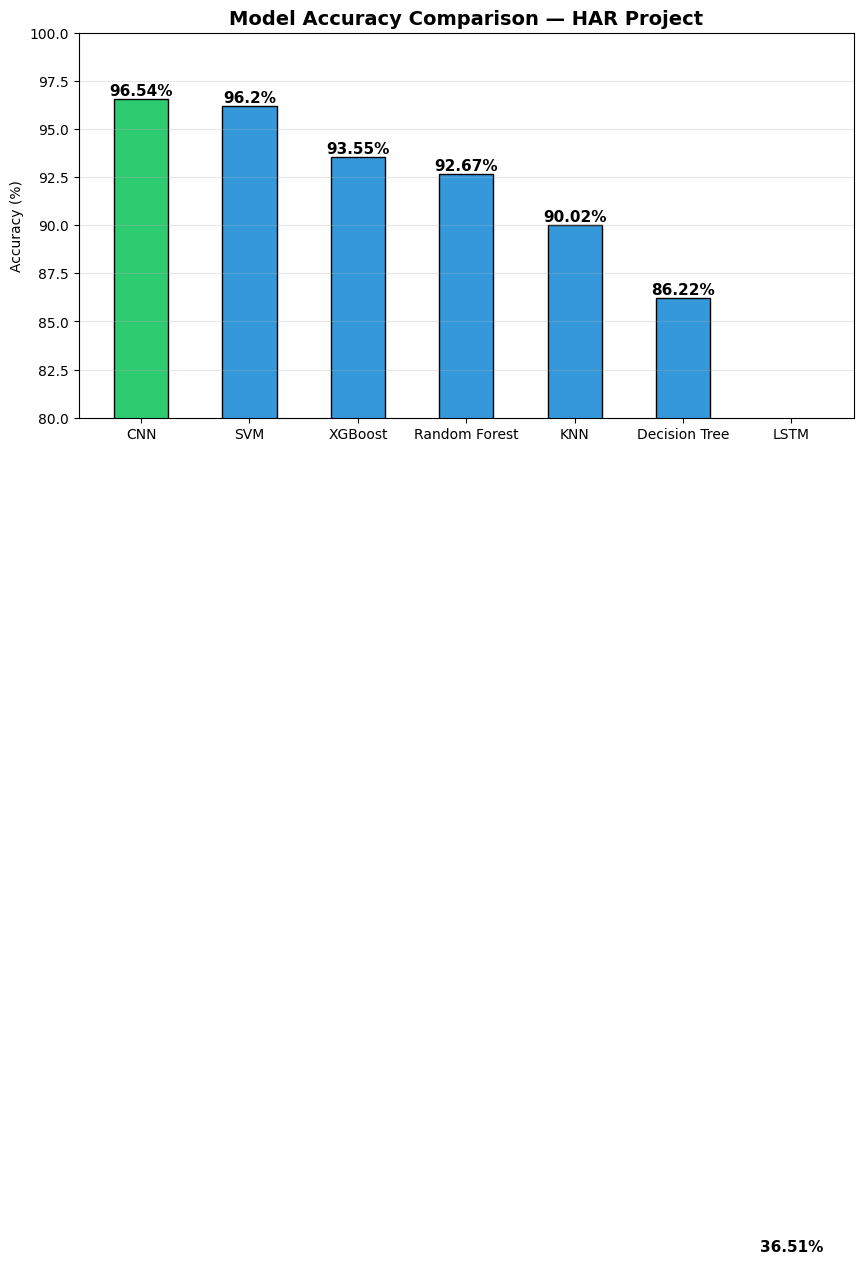

In [19]:
df = pd.DataFrame(list(results.items()), columns=['Model','Accuracy (%)']).sort_values('Accuracy (%)', ascending=False)
print('=' * 35)
print('     FINAL MODEL COMPARISON')
print('=' * 35)
print(df.to_string(index=False))
print('=' * 35)

colors = ['#2ecc71' if v == df['Accuracy (%)'].max() else '#3498db' for v in df['Accuracy (%)']]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(df['Model'], df['Accuracy (%)'], color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, df['Accuracy (%)']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{val}%', ha='center', fontweight='bold', fontsize=11)
ax.set_ylim([80, 100])
ax.set_title('Model Accuracy Comparison — HAR Project', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()